In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the CSV file
df = pd.read_csv('Housing.csv')

# 2. Display the first 10 rows
print("First 10 rows of the dataset:")
print(df.head(10))

# 3. Check rows and columns
print(f"\nThe dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

# 4. Identify Target and Features
# The target column is 'price'
print(f"\nTarget column: price")
print(f"Feature columns: {', '.join([col for col in df.columns if col != 'price'])}")

# 5. Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

First 10 rows of the dataset:
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no 

In [3]:
# 1. Handle missing values (fill or drop)
# This dataset usually has no missing values, but here's how you'd handle it:
# For numeric columns, fill with median; for categorical, fill with mode.
# df['column'].fillna(df['column'].median(), inplace=True)

# 2. Remove duplicate rows
initial_count = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {initial_count - df.shape[0]} duplicate rows.")

# 3. Convert categorical columns (yes/no) into numeric form using One-Hot Encoding
# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

# Apply one-hot encoding (drop_first avoids multicollinearity)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Keep only meaningful columns (all columns are meaningful here, we just keep the encoded version)
print(f"\nNew shape after encoding: {df_encoded.shape}")
print("First 5 rows of cleaned data:")
print(df_encoded.head())

# Store the cleaned dataframe for modeling
df_clean = df_encoded

Removed 0 duplicate rows.
Categorical columns to encode: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

New shape after encoding: (545, 14)
First 5 rows of cleaned data:
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False   

In [4]:
# 1. Split the data (80/20)
X = df_clean.drop('price', axis=1)  # Features
y = df_clean['price']               # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

# 2. Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 3. Evaluate Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- Linear Regression Performance ---")
print(f"MAE:  {mae_lr:,.2f}")
print(f"RMSE: {rmse_lr:,.2f}")
print(f"R² Score: {r2_lr:.4f}")

# 4. Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 5. Evaluate Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Random Forest Regressor Performance ---")
print(f"MAE:  {mae_rf:,.2f}")
print(f"RMSE: {rmse_rf:,.2f}")
print(f"R² Score: {r2_rf:.4f}")

# Compare
print("\n--- Model Comparison ---")
if r2_rf > r2_lr:
    print("Random Forest performs better than Linear Regression on this dataset.")
else:
    print("Linear Regression performs better than Random Forest on this dataset.")

Training set size: 436 rows
Test set size: 109 rows

--- Linear Regression Performance ---
MAE:  970,043.40
RMSE: 1,324,506.96
R² Score: 0.6529

--- Random Forest Regressor Performance ---
MAE:  1,021,546.04
RMSE: 1,400,565.97
R² Score: 0.6119

--- Model Comparison ---
Linear Regression performs better than Random Forest on this dataset.


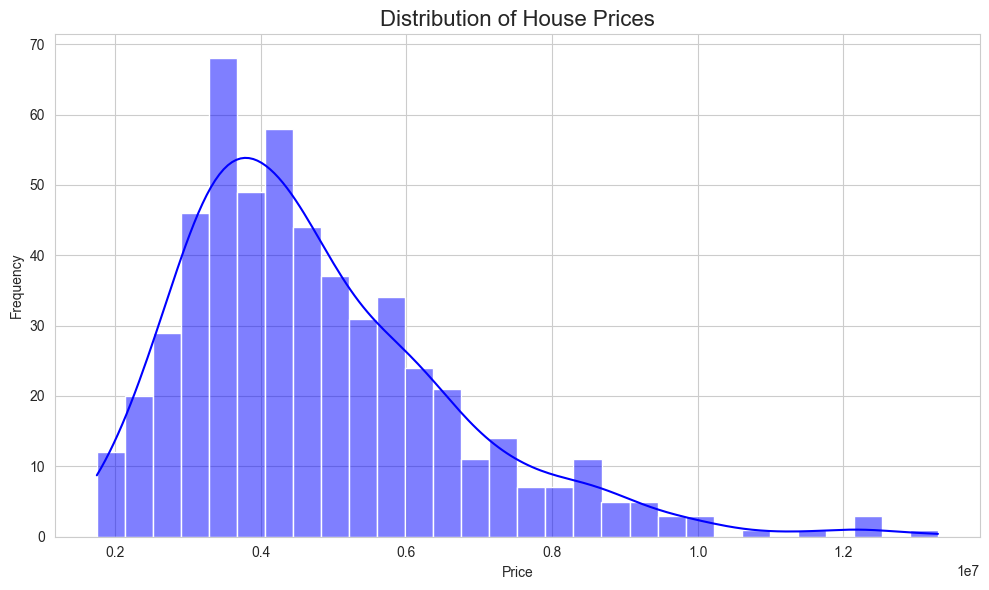

Top features correlated with price:
price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


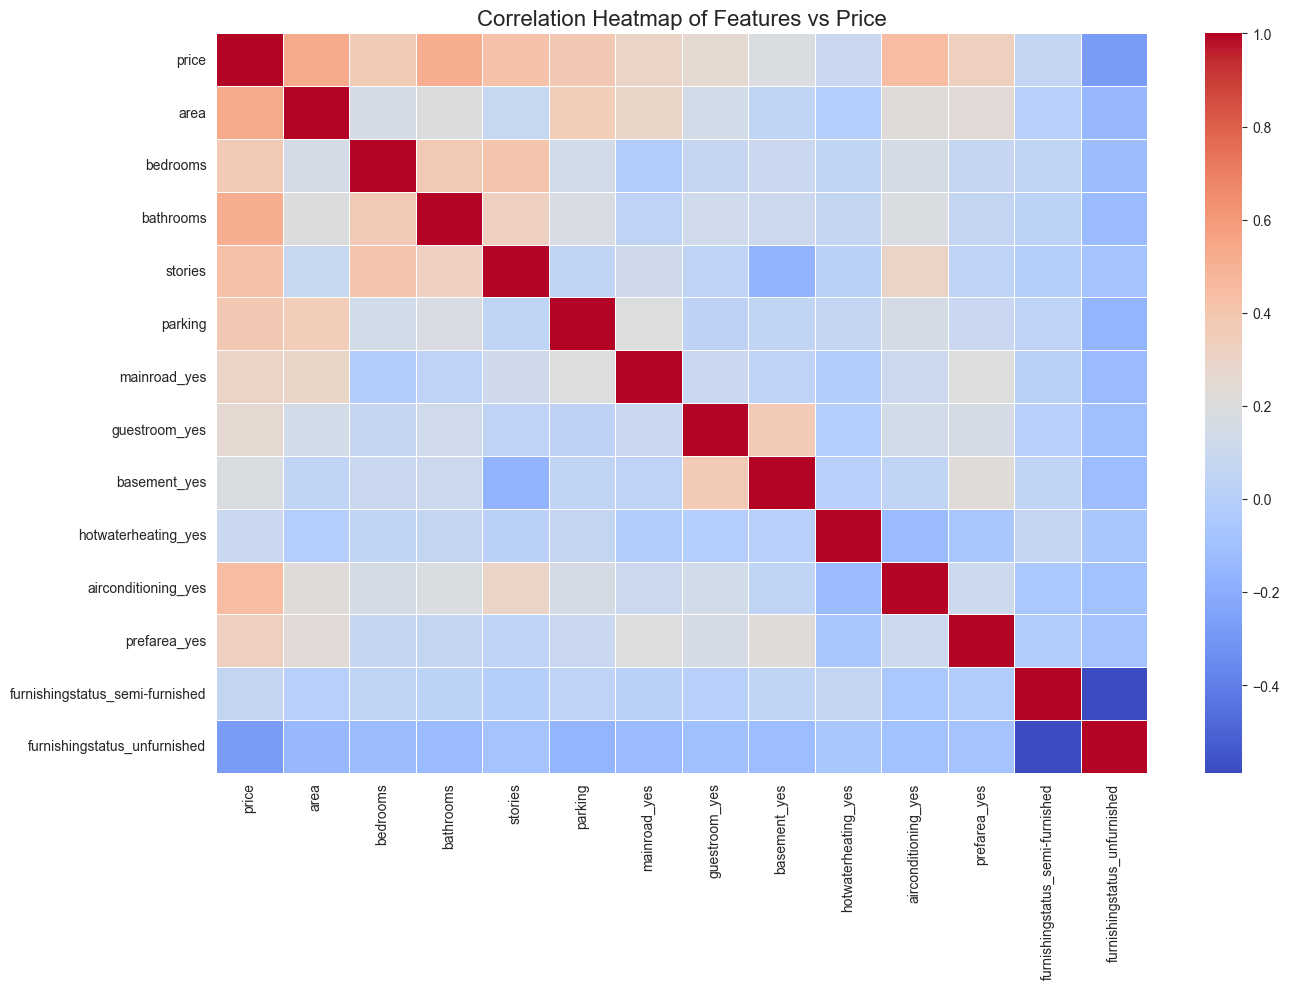

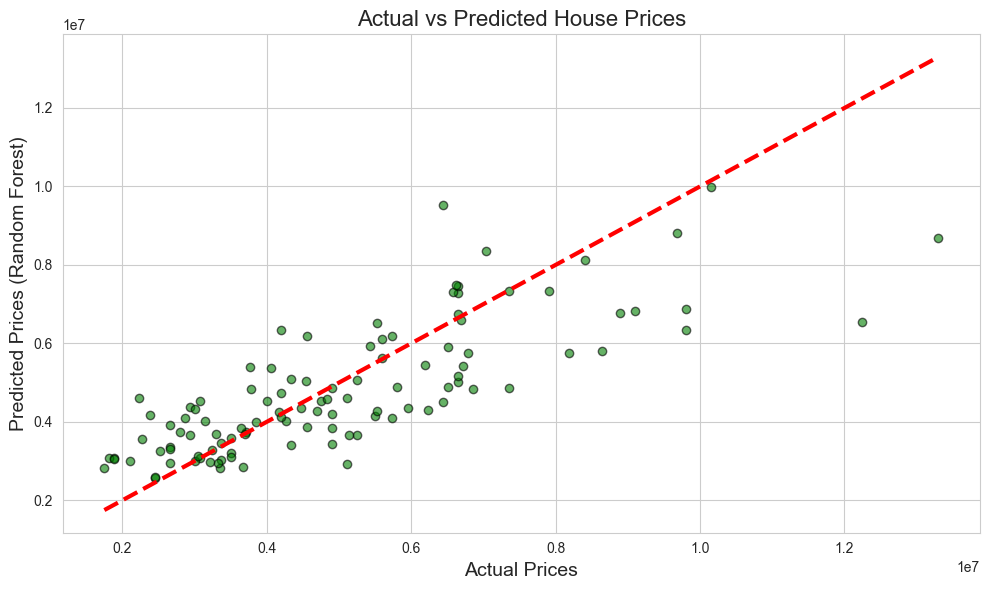

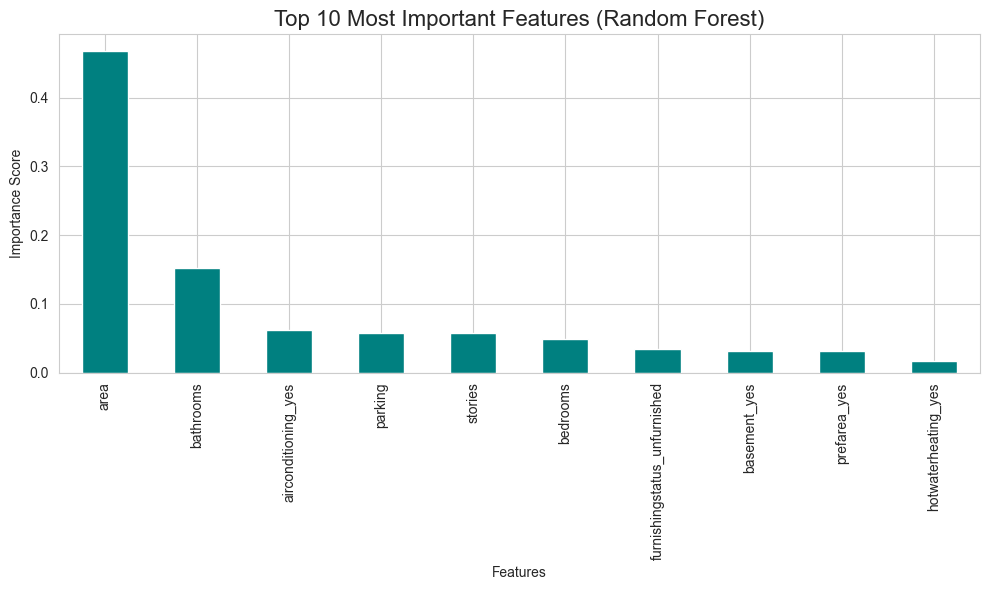

In [5]:
# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ---------- Chart 1: Histogram of House Prices ----------
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True, color='blue')
plt.title('Distribution of House Prices', fontsize=16)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('charts/histogram_prices.png')  # Save the image
plt.show()

# ---------- Chart 2: Correlation Heatmap ----------
plt.figure(figsize=(14, 10))
# Select only numeric columns for correlation (they already are after encoding)
correlation_matrix = df_clean.corr()
# Sort correlations with 'price' to find top features
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print("Top features correlated with price:")
print(price_corr)

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features vs Price', fontsize=16)
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png')
plt.show()

# ---------- Chart 3: Your Own Choice (Actual vs Predicted Scatter Plot) ----------
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='green', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
plt.xlabel('Actual Prices', fontsize=14)
plt.ylabel('Predicted Prices (Random Forest)', fontsize=14)
plt.title('Actual vs Predicted House Prices', fontsize=16)
plt.tight_layout()
plt.savefig('charts/actual_vs_predicted.png')
plt.show()

# (Bonus: Feature Importance from Random Forest)
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_importance.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Most Important Features (Random Forest)', fontsize=16)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/feature_importance.png')
plt.show()